# Reporte de Resultados de Modelos

Este notebook presenta un análisis completo de los resultados obtenidos por los 4 modelos de clasificación:
- LightGBM
- Random Forest
- XGBoost
- Decision Tree

Los datos se cargan desde los archivos CSV generados durante la evaluación.

## Importar librerías y configurar

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Configurar estilo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

# Ruta de datos
RESULTS_DIR = Path('.').resolve()
print(f'Directorio de resultados: {RESULTS_DIR}')
print(f'Archivos disponibles:')
for f in sorted(RESULTS_DIR.glob('*.csv')):
    print(f'  • {f.name}')

Directorio de resultados: /home/francisco/maestria/trabajo final/tf-austral/results
Archivos disponibles:
  • feature_importance_decision_tree_20260526_194207.csv
  • feature_importance_decision_tree_20260527_205636.csv
  • feature_importance_lightgbm_20260526_194207.csv
  • feature_importance_lightgbm_20260527_205636.csv
  • feature_importance_randomforest_20260526_194207.csv
  • feature_importance_randomforest_20260527_205636.csv
  • feature_importance_xgboost_20260526_194207.csv
  • feature_importance_xgboost_20260527_205636.csv
  • matriz_confusion_decision_tree_20260526_190413.csv
  • matriz_confusion_decision_tree_20260526_194207.csv
  • matriz_confusion_decision_tree_20260527_205636.csv
  • matriz_confusion_decision_tree_base_20260527_205636.csv
  • matriz_confusion_lightgbm_20260526_190413.csv
  • matriz_confusion_lightgbm_20260526_194207.csv
  • matriz_confusion_lightgbm_20260527_205636.csv
  • matriz_confusion_randomforest_20260526_190413.csv
  • matriz_confusion_randomforest

## Cargar datos

In [2]:
# Encontrar archivos más recientes
def get_latest_file(pattern):
    files = list(RESULTS_DIR.glob(pattern))
    if not files:
        return None
    return sorted(files, key=lambda x: x.stat().st_mtime, reverse=True)[0]

# Cargar archivos
metricas_global_file = get_latest_file('metricas_globales_*.csv')
consolidado_file = get_latest_file('resultados_consolidados_*.csv')
resumen_file = get_latest_file('resumen_ejecutivo_*.csv')
matriz_files = sorted(RESULTS_DIR.glob('matriz_confusion_*.csv'), key=lambda x: x.stat().st_mtime, reverse=True)
predicciones_files = sorted(RESULTS_DIR.glob('predicciones_*.csv'), key=lambda x: x.stat().st_mtime, reverse=True)

metricas_global = pd.read_csv(metricas_global_file) if metricas_global_file else None
consolidado = pd.read_csv(consolidado_file) if consolidado_file else None
resumen = pd.read_csv(resumen_file) if resumen_file else None

print(f'✓ Archivos cargados exitosamente')
print(f'\nMétricas globales: {metricas_global.shape}')
print(f'Consolidado: {consolidado.shape}')
print(f'Resumen: {resumen.shape}')
print(f'Matrices de confusión: {len(matriz_files)}')
print(f'Predicciones: {len(predicciones_files)}')

✓ Archivos cargados exitosamente

Métricas globales: (5, 7)
Consolidado: (65, 9)
Resumen: (5, 7)
Matrices de confusión: 13
Predicciones: 13


## Resumen Ejecutivo

In [3]:
print('='*100)
print('RESUMEN EJECUTIVO - RESULTADOS POR MODELO')
print('='*100)
print(resumen.to_string(index=False))
print('='*100)

RESUMEN EJECUTIVO - RESULTADOS POR MODELO
            Modelo       Estudio  Accuracy    Kappa  F1-Score Macro  Precisión Macro  Recall Macro
           xgboost xgboost_final  0.966794 0.958212        0.951013         0.950625      0.952794
          lightgbm    LGBM_final  0.966715 0.958138        0.947615         0.947134      0.950387
      randomforest      RF_final  0.958276 0.947469        0.938799         0.944224      0.937630
     decision_tree   model_final  0.927752 0.908138        0.909798         0.927360      0.897849
decision_tree_base    base_model  0.788382 0.720672        0.613243         0.689680      0.584667


## 1. Comparación de Métricas Globales

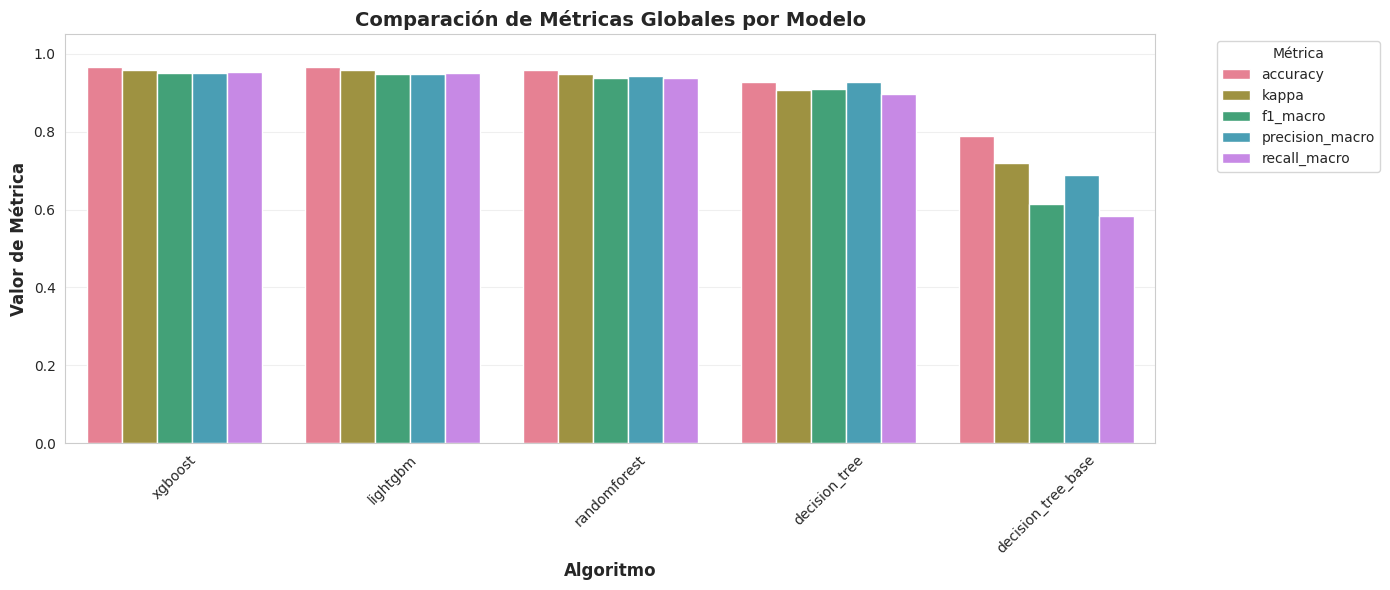


Detalles numéricos:
         algorithm  accuracy    kappa  f1_macro
           xgboost  0.966794 0.958212  0.951013
          lightgbm  0.966715 0.958138  0.947615
      randomforest  0.958276 0.947469  0.938799
     decision_tree  0.927752 0.908138  0.909798
decision_tree_base  0.788382 0.720672  0.613243


In [ ]:
# Preparar datos para visualización - excluir decision_tree para evitar duplicado con decision_tree_base
metrics_plot = metricas_global[metricas_global['algorithm'] != 'decision_tree'].copy()
metrics_plot = metrics_plot[['algorithm', 'accuracy', 'kappa', 'f1_macro', 'precision_macro', 'recall_macro']]
metrics_plot_melted = metrics_plot.melt(id_vars=['algorithm'], var_name='metric', value_name='value')

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=metrics_plot_melted, x='algorithm', y='value', hue='metric', ax=ax, palette='husl')
ax.set_ylabel('Valor de Métrica', fontsize=12, fontweight='bold')
ax.set_xlabel('Algoritmo', fontsize=12, fontweight='bold')
ax.set_title('Comparación de Métricas Globales por Modelo', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Métrica', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nDetalles numéricos (4 modelos principales + decision_tree_base):')
print(metricas_global[metricas_global['algorithm'] != 'decision_tree'][['algorithm', 'accuracy', 'kappa', 'f1_macro']].to_string(index=False))

## 2. Accuracy y Kappa por Modelo

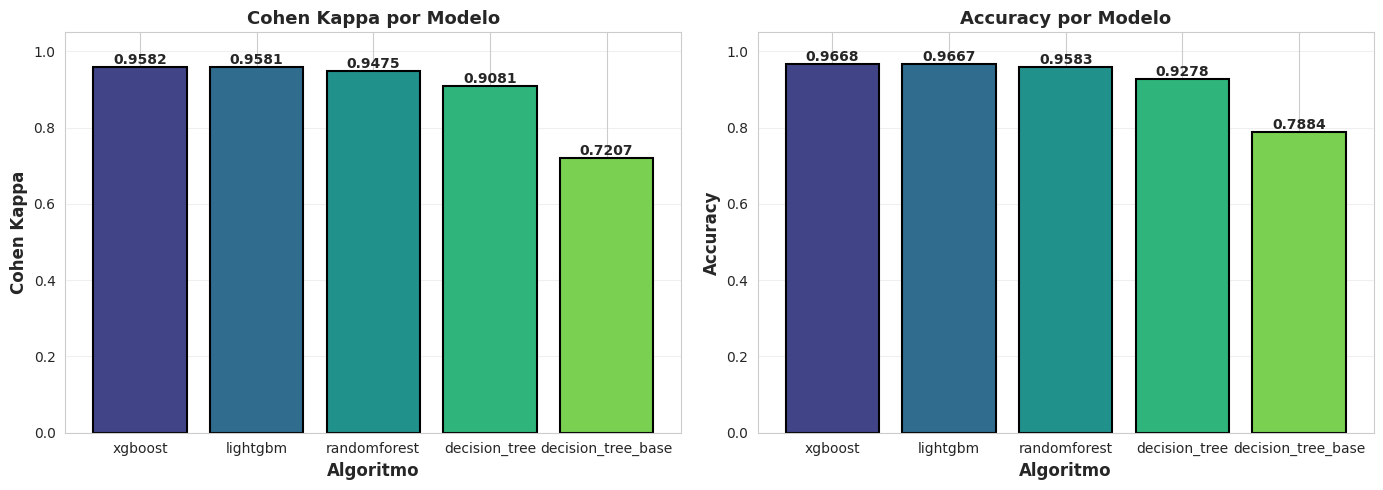

In [5]:
fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
colors_acc = plt.cm.viridis(np.linspace(0.2, 0.8, len(metricas_global)))
bars1 = ax1.bar(metricas_global['algorithm'], metricas_global['accuracy'], color=colors_acc, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_xlabel('Algoritmo', fontsize=12, fontweight='bold')
ax1.set_title('Accuracy por Modelo', fontsize=13, fontweight='bold')
ax1.set_ylim(0, 1.05)
ax1.grid(axis='y', alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontweight='bold')

# Kappa
bars2 = ax2.bar(metricas_global['algorithm'], metricas_global['kappa'], color=colors_acc, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Cohen Kappa', fontsize=12, fontweight='bold')
ax2.set_xlabel('Algoritmo', fontsize=12, fontweight='bold')
ax2.set_title('Cohen Kappa por Modelo', fontsize=13, fontweight='bold')
ax2.set_ylim(0, 1.05)
ax2.grid(axis='y', alpha=0.3)

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 3. F1-Score, Precisión y Recall Macro

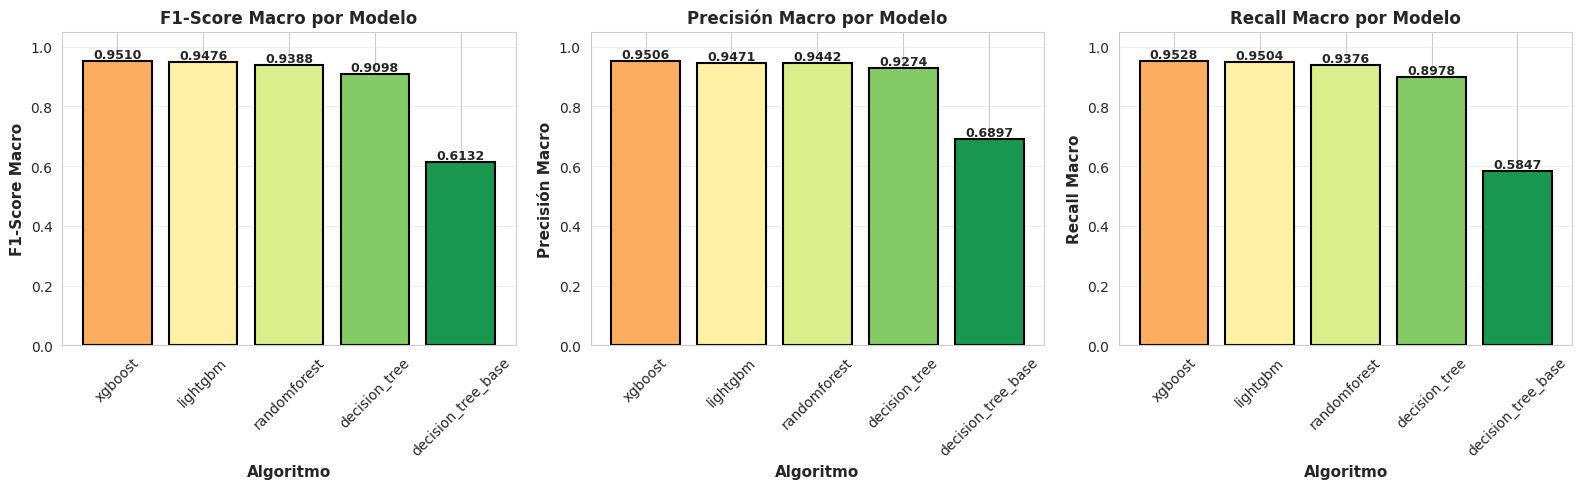

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics_detail = [
    ('f1_macro', 'F1-Score Macro', 0),
    ('precision_macro', 'Precisión Macro', 1),
    ('recall_macro', 'Recall Macro', 2)
]

for metric_col, metric_name, ax_idx in metrics_detail:
    colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(metricas_global)))
    bars = axes[ax_idx].bar(metricas_global['algorithm'], metricas_global[metric_col], 
                            color=colors, edgecolor='black', linewidth=1.5)
    axes[ax_idx].set_ylabel(metric_name, fontsize=11, fontweight='bold')
    axes[ax_idx].set_xlabel('Algoritmo', fontsize=11, fontweight='bold')
    axes[ax_idx].set_title(f'{metric_name} por Modelo', fontsize=12, fontweight='bold')
    axes[ax_idx].set_ylim(0, 1.05)
    axes[ax_idx].grid(axis='y', alpha=0.3)
    axes[ax_idx].tick_params(axis='x', rotation=45)
    
    for bar in bars:
        height = bar.get_height()
        axes[ax_idx].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Heatmap de Correlación de Métricas

## 5. Métricas por Clase

In [8]:
# Filtrar métricas por clase
consolidado_by_class = consolidado[consolidado['class'] != 'weighted avg'].copy()
consolidado_by_class = consolidado_by_class[consolidado_by_class['class'] != 'macro avg'].copy()

print('\nMÉTRICAS POR CLASE Y MODELO')
print('='*100)
for algo in consolidado_by_class['algorithm'].unique():
    print(f'\n{algo.upper()}:')
    print('-'*100)
    algo_data = consolidado_by_class[consolidado_by_class['algorithm'] == algo][['class', 'precision', 'recall', 'f1-score']]
    print(algo_data.to_string(index=False))
print('='*100)


MÉTRICAS POR CLASE Y MODELO

XGBOOST:
----------------------------------------------------------------------------------------------------
                class  precision   recall  f1-score
                   GF   0.905934 0.921053  0.913431
                  PTE   1.000000 1.000000  1.000000
              Sueldos   0.978375 0.966030  0.972163
             Viaticos   0.983778 0.962585  0.973066
          Proveedores   0.976183 0.975419  0.975801
                   FF   1.000000 1.000000  1.000000
            Servicios   0.942081 0.940379  0.941230
Retenciones de sueldo   0.961075 0.963716  0.962394
           Honorarios   0.923926 0.976654  0.949559
         Contratistas   0.866370 0.825902  0.845652
           Alquileres   0.976959 0.879668  0.925764
                  CCF   0.862745 1.000000  0.926316
            Subsidios   0.980703 0.974914  0.977800

LIGHTGBM:
----------------------------------------------------------------------------------------------------
                clas

## 6. Distribución de Precisión, Recall y F1-Score por Clase

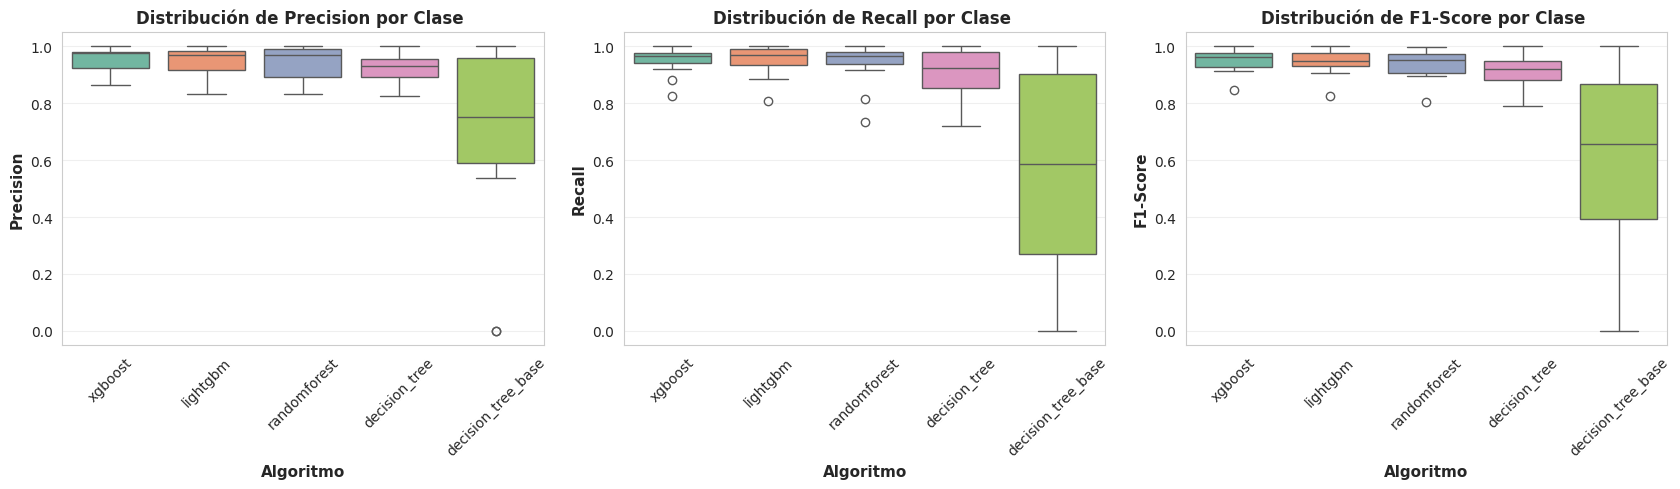

In [13]:
consolidado_clean = consolidado[consolidado['class'] != 'weighted avg'].copy()
consolidado_clean = consolidado_clean[consolidado_clean['class'] != 'macro avg'].copy()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

metrics_cols = ['precision', 'recall', 'f1-score']
colors_palette = plt.cm.Set3(np.linspace(0, 1, len(consolidado_clean['algorithm'].unique())))

# Zoom desde 0.7
for idx, metric in enumerate(metrics_cols):
    sns.boxplot(data=consolidado_clean, x='algorithm', y=metric, ax=axes[idx], palette='Set2')
    axes[idx].set_ylabel(metric.title(), fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Algoritmo', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'Distribución de {metric.title()} por Clase ', fontsize=12, fontweight='bold')
    #axes[idx].set_ylim(0.4, 1.02)
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Matrices de Confusión

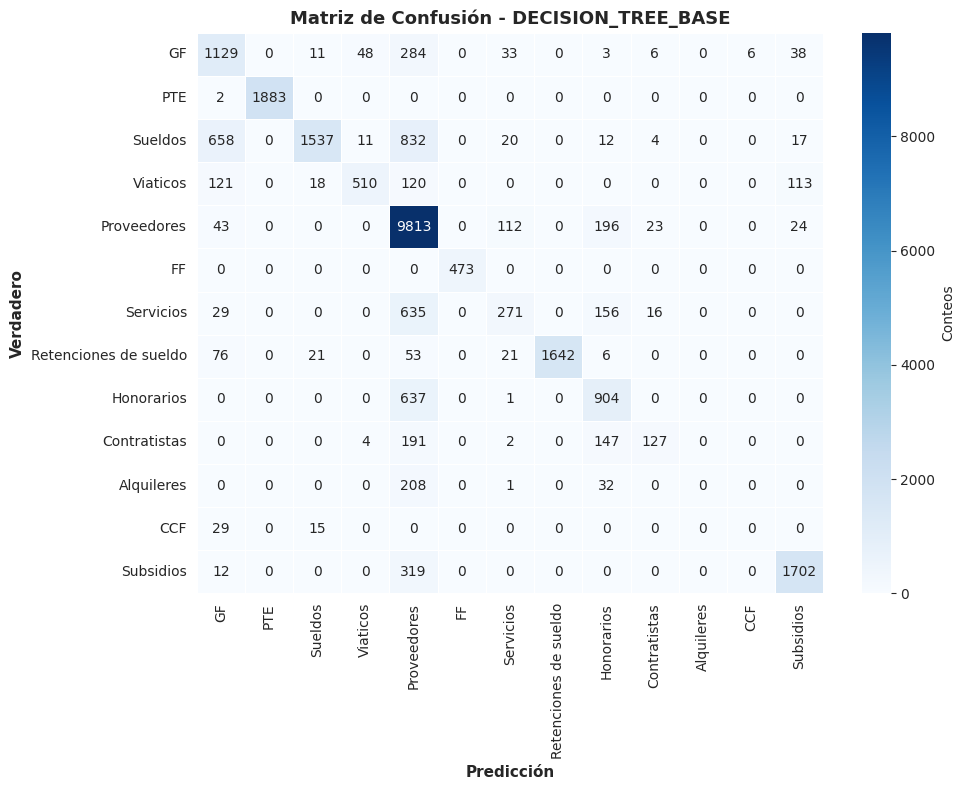

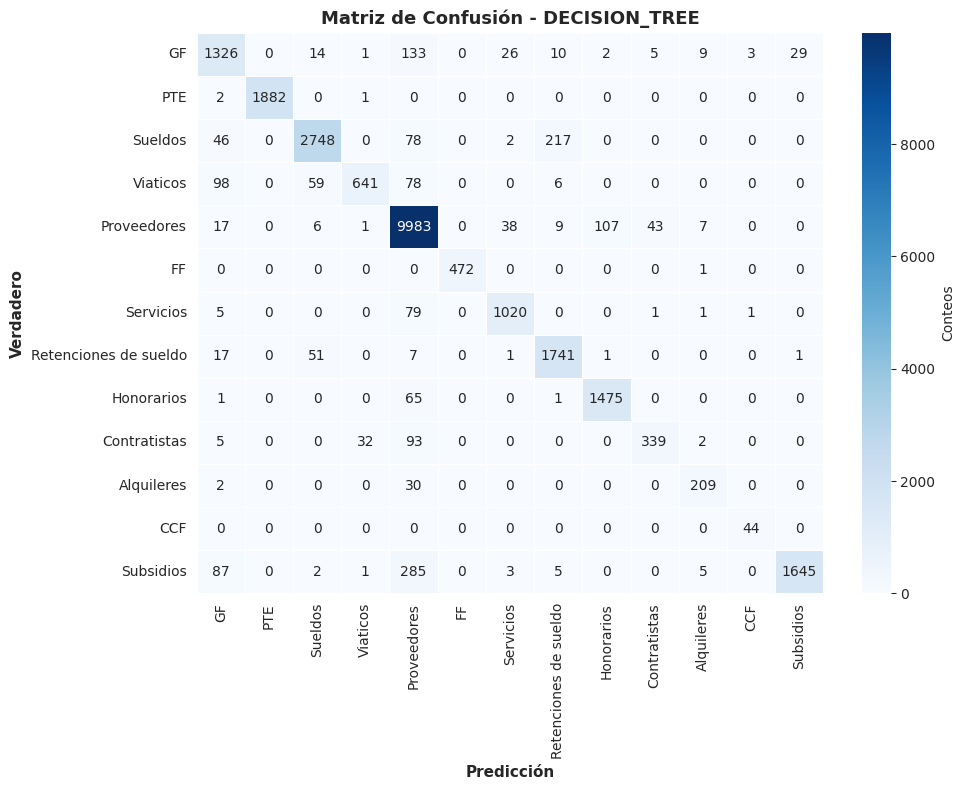

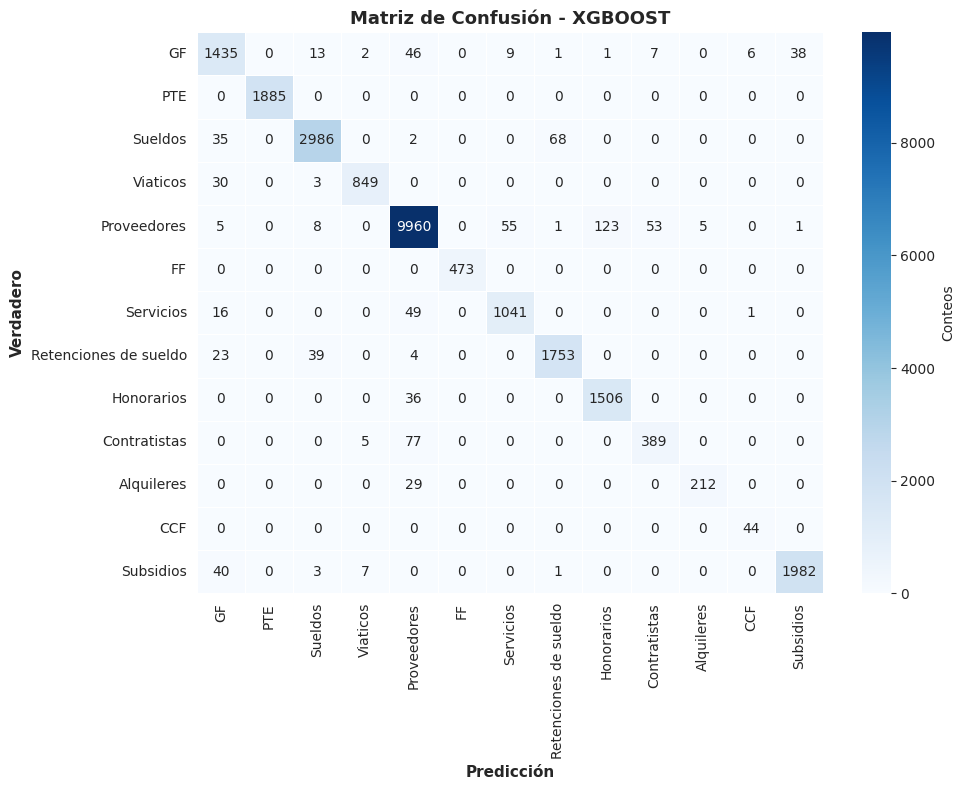

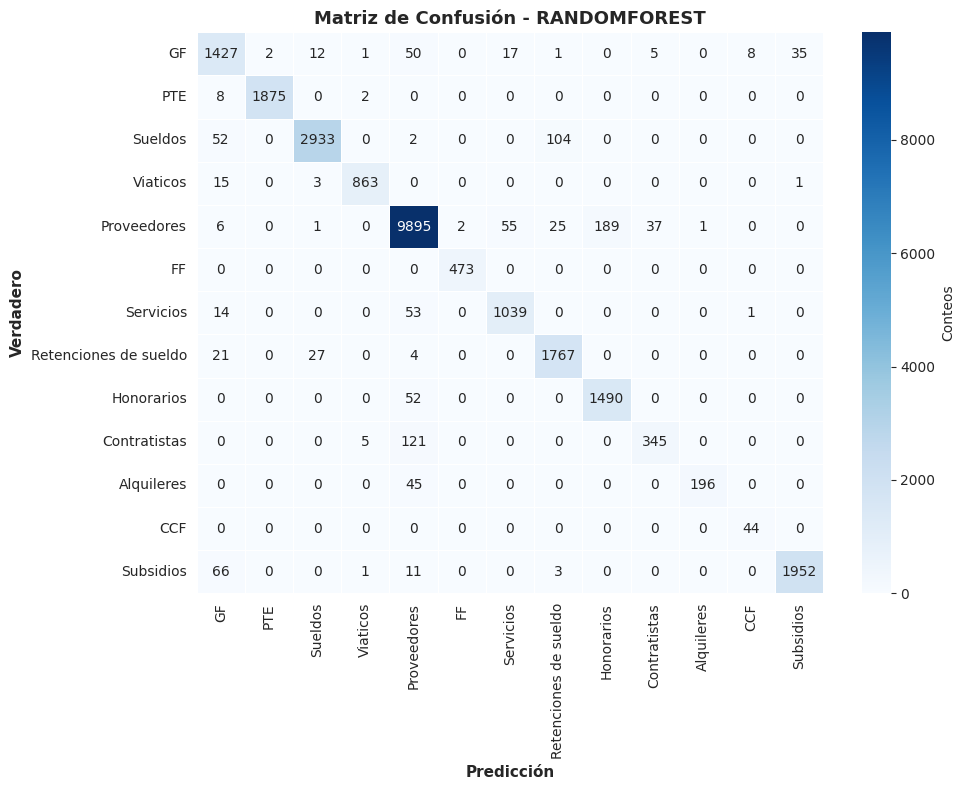

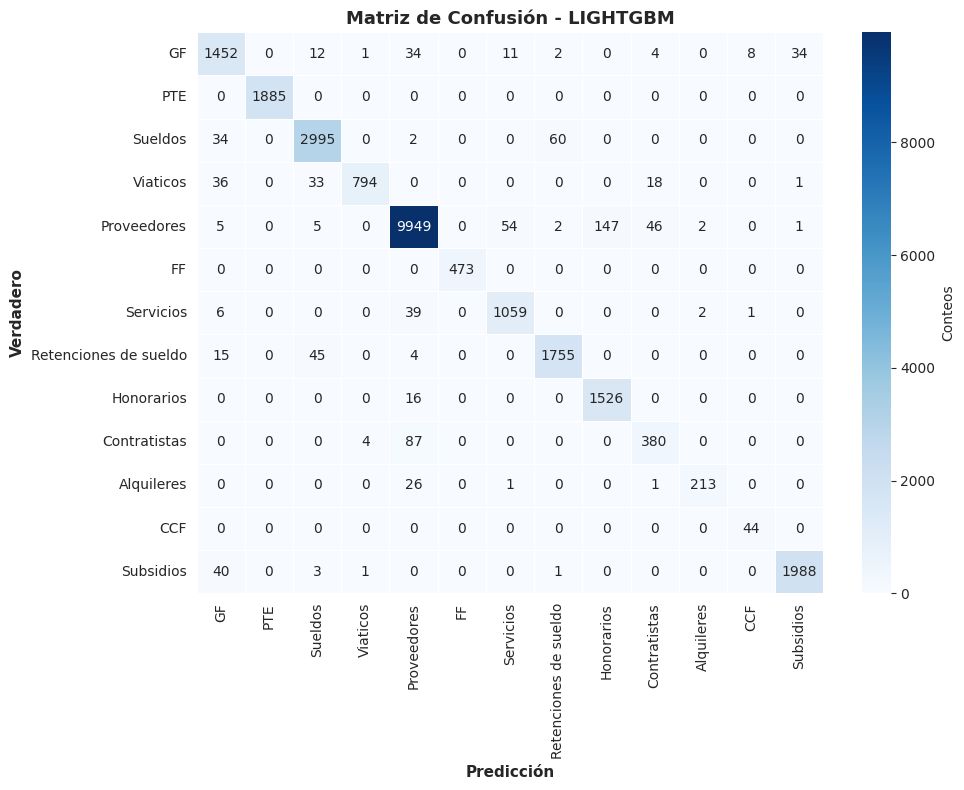

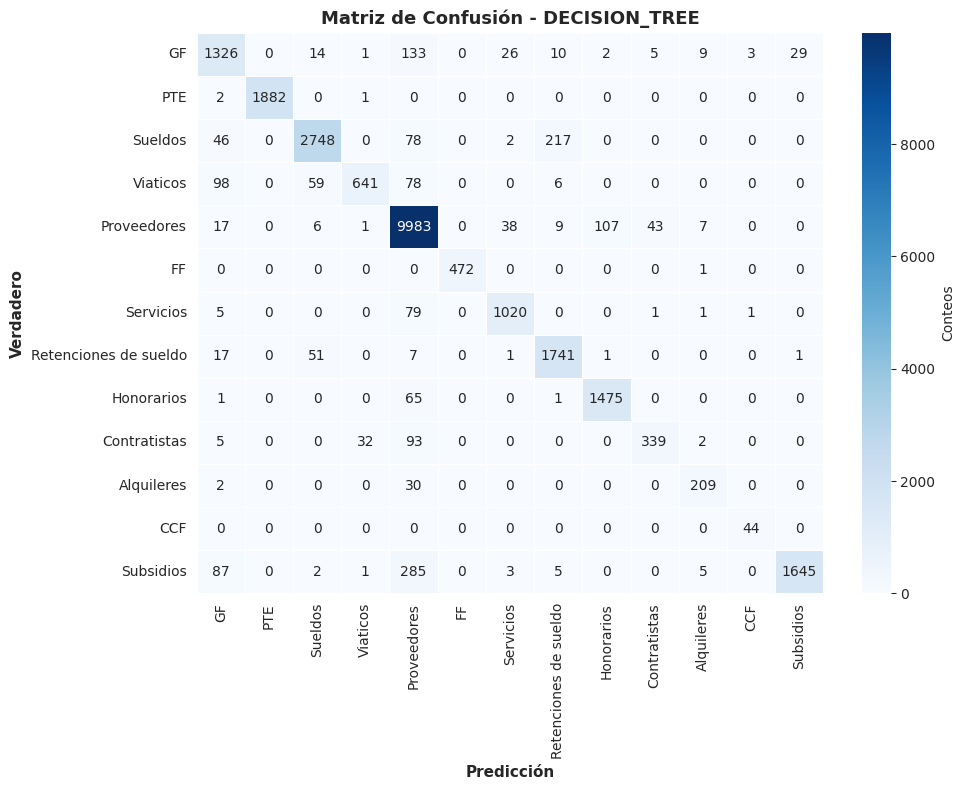

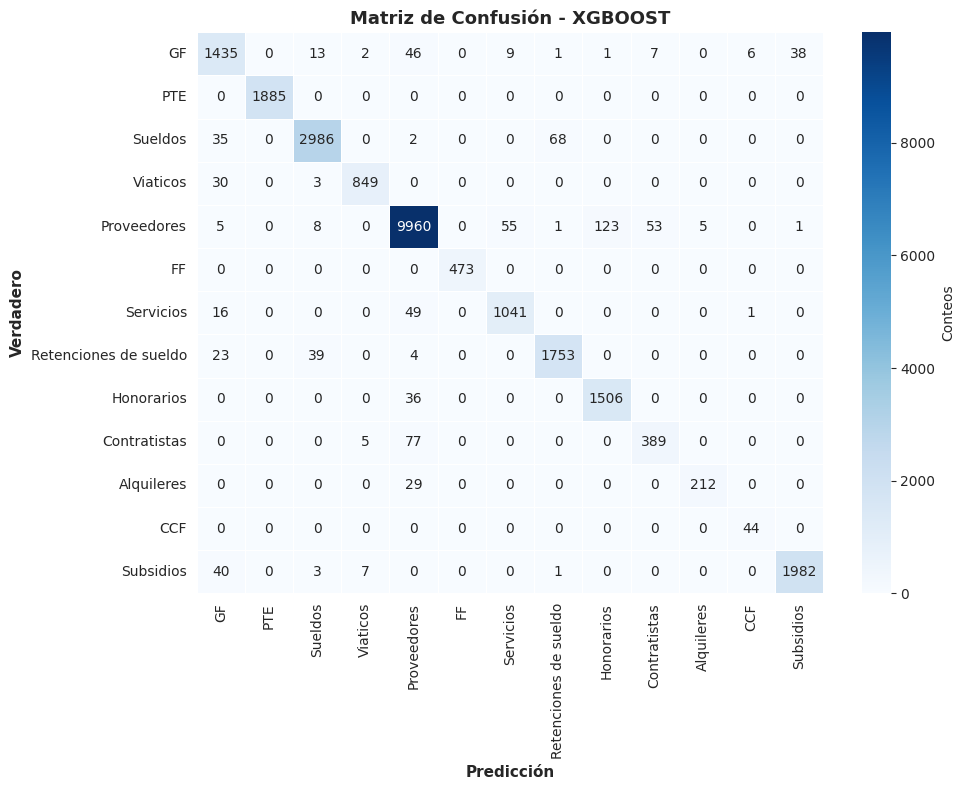

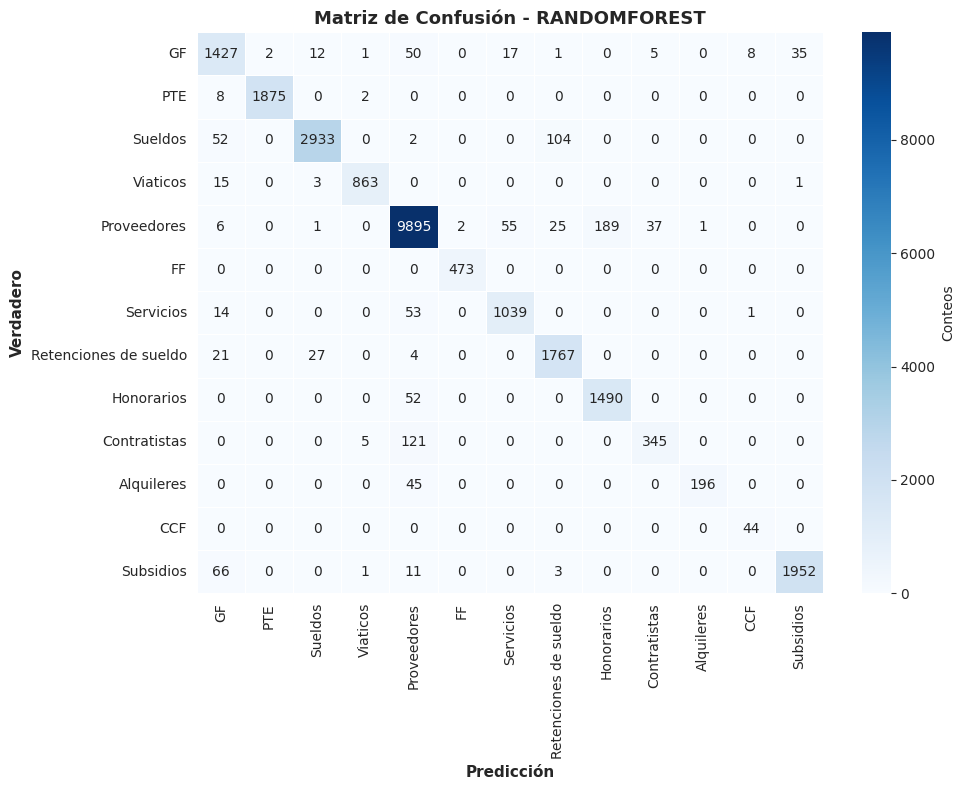

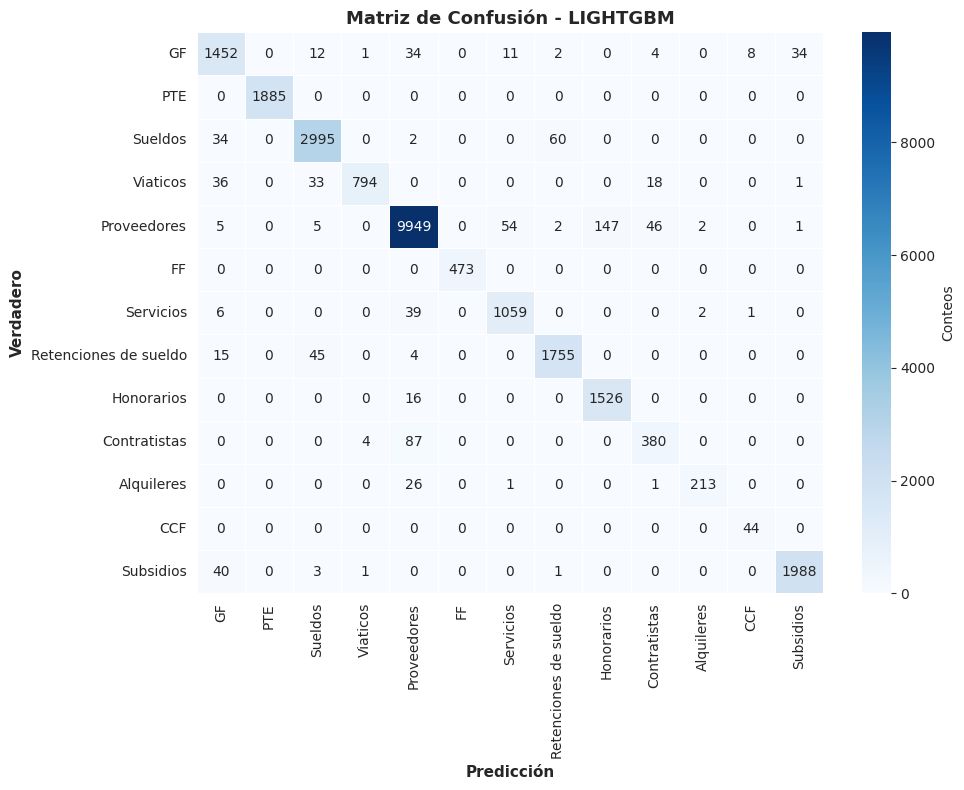

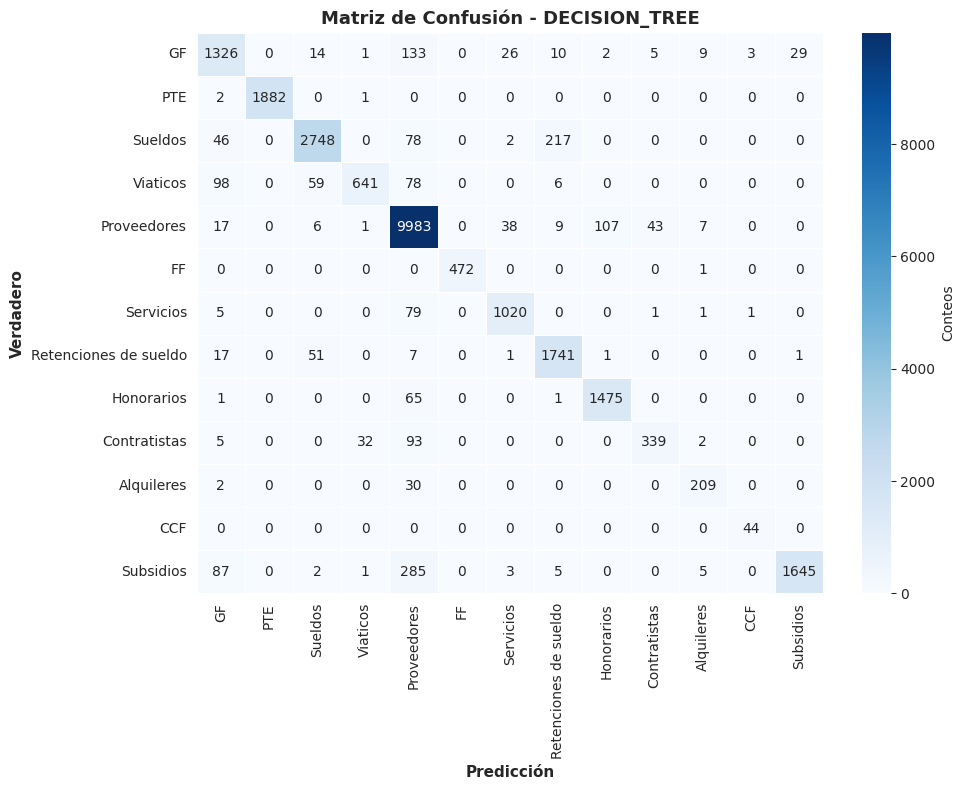

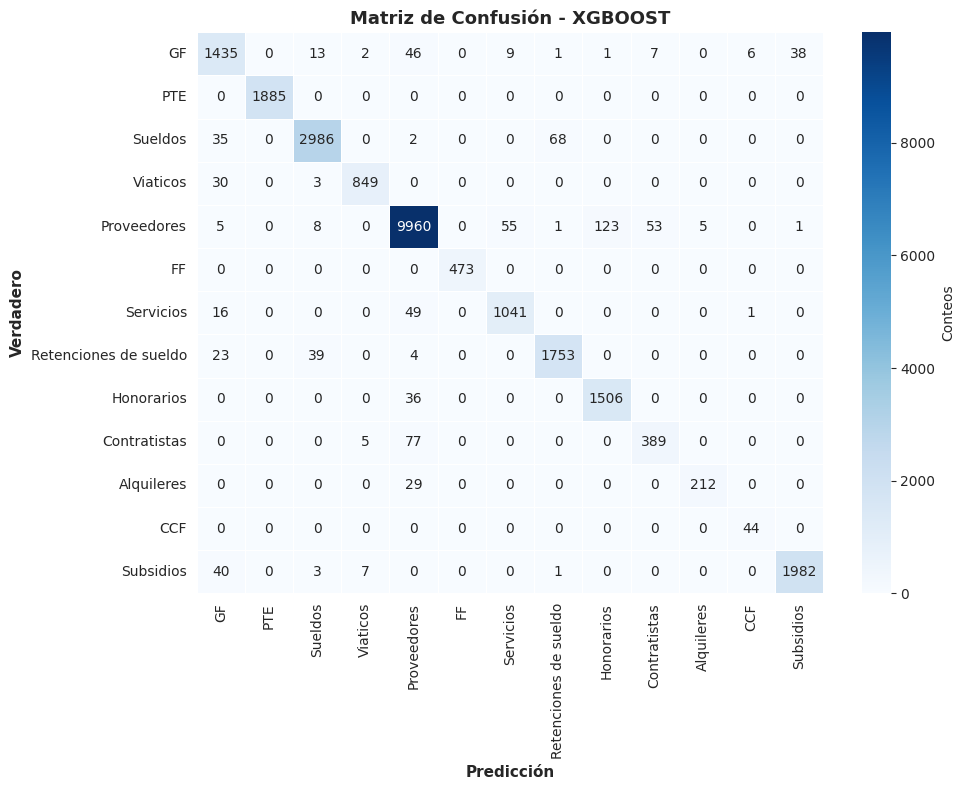

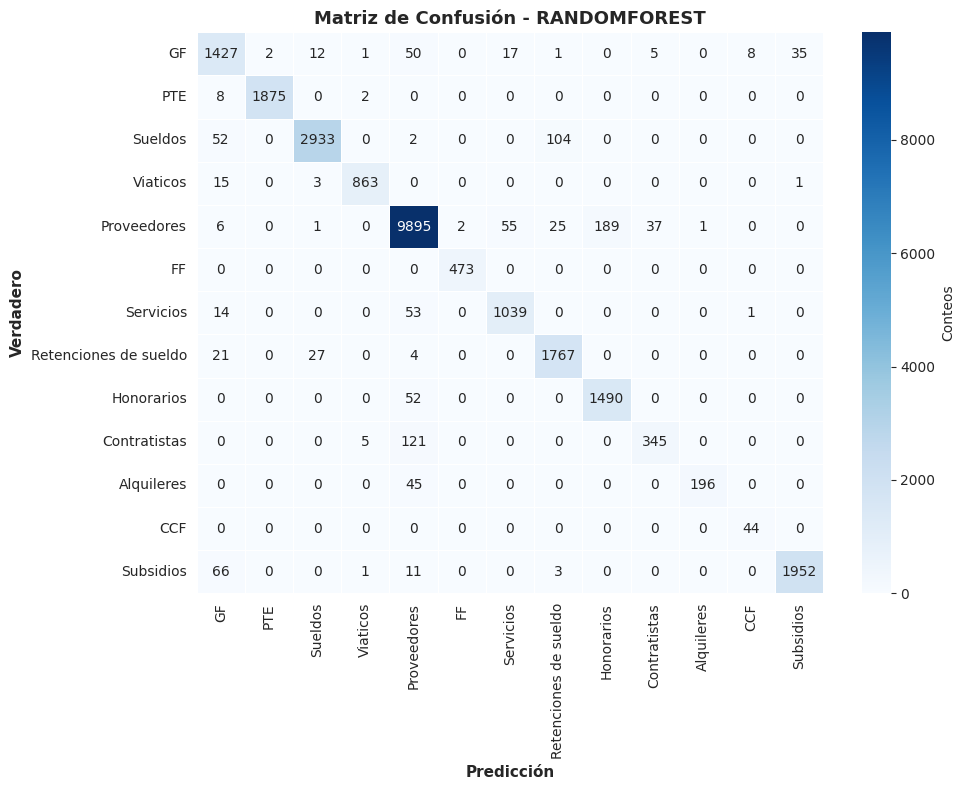

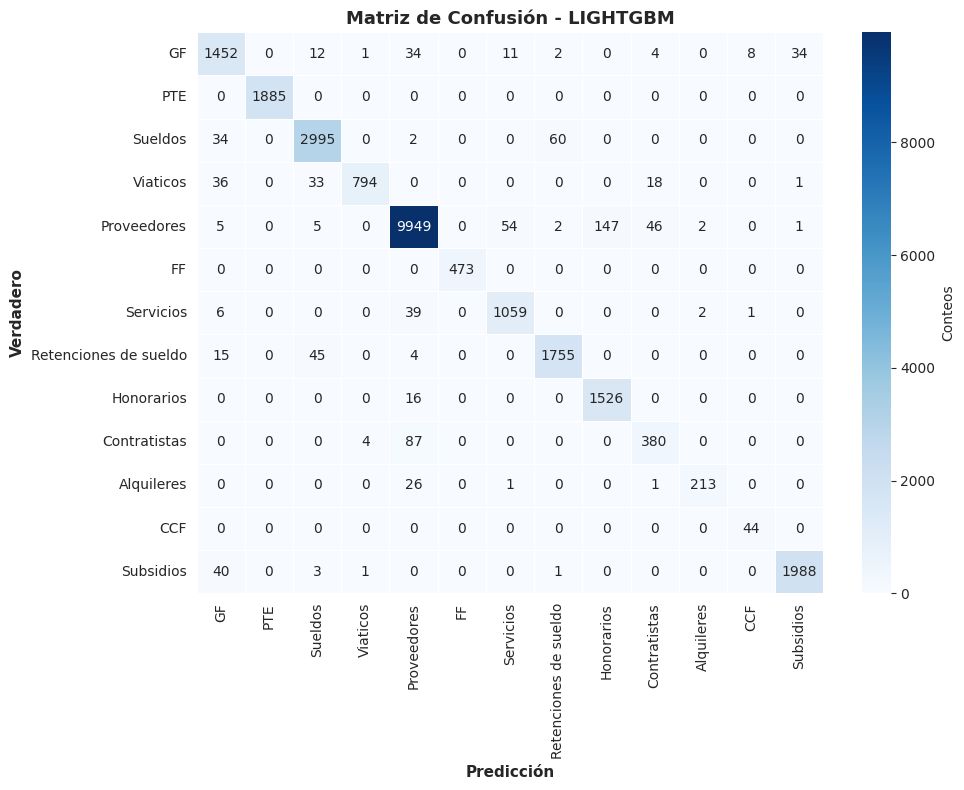

In [16]:
# Cargar y visualizar matrices de confusión
for matriz_file in matriz_files:  # Incluir todas las matrices
    algo_name = matriz_file.stem.replace('matriz_confusion_', '').rsplit('_', 2)[0]
    cm = pd.read_csv(matriz_file, index_col=0)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Conteos'}, ax=ax, linewidths=0.5)
    ax.set_title(f'Matriz de Confusión - {algo_name.upper()}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Verdadero', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicción', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 8. Tasa de Error por Modelo

DEBUG: Buscando archivos de predicciones...
  ✓ xgboost: predicciones_xgboost_20260527_205636.csv
  ✓ lightgbm: predicciones_lightgbm_20260527_205636.csv
  ✓ randomforest: predicciones_randomforest_20260527_205636.csv
  ✓ decision_tree: predicciones_decision_tree_20260527_205636.csv
  ✓ decision_tree_base: predicciones_decision_tree_base_20260527_205636.csv


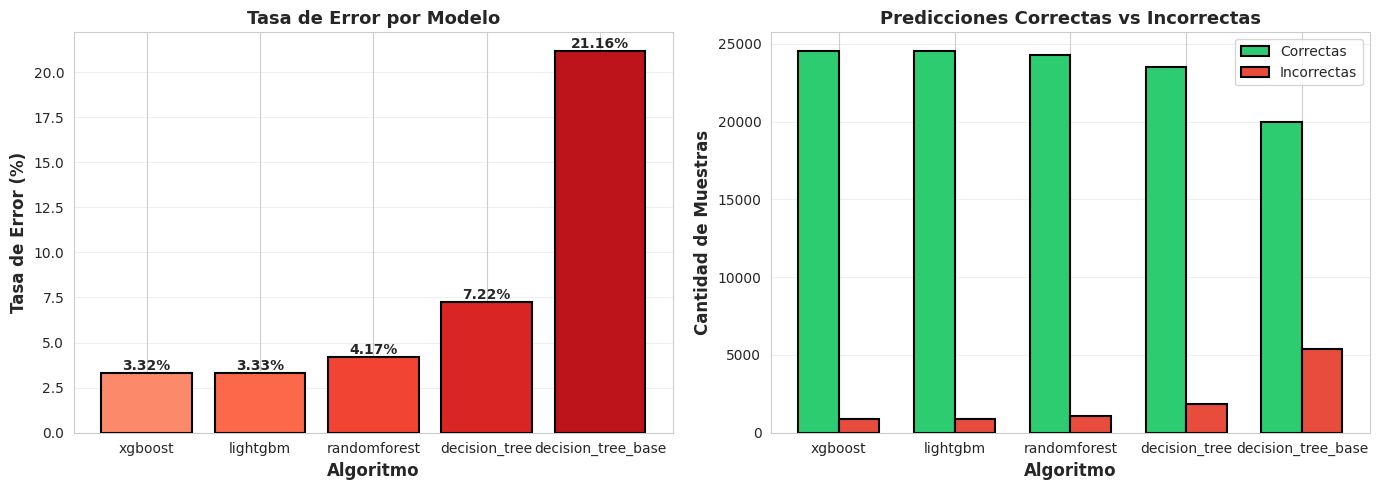


Detalle de tasas de error:
         algorithm  error_rate  accuracy  total_samples
           xgboost    0.033206  0.966794          25357
          lightgbm    0.033285  0.966715          25357
      randomforest    0.041724  0.958276          25357
     decision_tree    0.072248  0.927752          25357
decision_tree_base    0.211618  0.788382          25357


In [23]:
# Calcular tasas de error usando solo los algoritmos de metricas_global (5 modelos)
error_data = []
print("DEBUG: Buscando archivos de predicciones...")
for algo in metricas_global['algorithm'].unique():
    # Buscar el archivo de predicciones correspondiente de forma más específica
    pred_file = None
    
    # Para decision_tree: buscar exactamente predicciones_decision_tree_ seguido de números (timestamp)
    # pero excluir decision_tree_base
    if algo == 'decision_tree':
        for pf in predicciones_files:
            # Buscar predicciones_decision_tree_TIMESTAMP pero NO predicciones_decision_tree_base_
            if pf.stem.startswith('predicciones_decision_tree_') and 'decision_tree_base' not in pf.stem:
                pred_file = pf
                break
    else:
        # Para otros algoritmos, búsqueda normal
        for pf in predicciones_files:
            if pf.stem.startswith(f'predicciones_{algo}_'):
                pred_file = pf
                break
    
    if pred_file is None:
        print(f"  ❌ {algo}: No se encontró archivo")
        continue
    
    print(f"  ✓ {algo}: {pred_file.name}")
    pred_df = pd.read_csv(pred_file)
    error_rate = 1 - (pred_df['correcto'].sum() / len(pred_df))
    error_data.append({
        'algorithm': algo,
        'error_rate': error_rate,
        'accuracy': 1 - error_rate,
        'total_samples': len(pred_df)
    })

error_df = pd.DataFrame(error_data)
# Ordenar según el orden de metricas_global
error_df['algorithm'] = pd.Categorical(error_df['algorithm'], categories=metricas_global['algorithm'], ordered=True)
error_df = error_df.sort_values('algorithm').reset_index(drop=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Tasa de Error
colors_error = plt.cm.Reds(np.linspace(0.4, 0.8, len(metricas_global)))
bars1 = ax1.bar(error_df['algorithm'], error_df['error_rate'] * 100, color=colors_error, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Tasa de Error (%)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Algoritmo', fontsize=12, fontweight='bold')
ax1.set_title('Tasa de Error por Modelo', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%', ha='center', va='bottom', fontweight='bold')

# Distribución de correctas vs incorrectas
correctas = error_df['total_samples'] * (1 - error_df['error_rate'])
incorrectas = error_df['total_samples'] * error_df['error_rate']

x = np.arange(len(error_df))
width = 0.35

bars2_1 = ax2.bar(x - width/2, correctas, width, label='Correctas', color='#2ecc71', edgecolor='black', linewidth=1.5)
bars2_2 = ax2.bar(x + width/2, incorrectas, width, label='Incorrectas', color='#e74c3c', edgecolor='black', linewidth=1.5)

ax2.set_ylabel('Cantidad de Muestras', fontsize=12, fontweight='bold')
ax2.set_xlabel('Algoritmo', fontsize=12, fontweight='bold')
ax2.set_title('Predicciones Correctas vs Incorrectas', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(error_df['algorithm'])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('\nDetalle de tasas de error:')
print(error_df.to_string(index=False))

## 9. Soporte por Clase

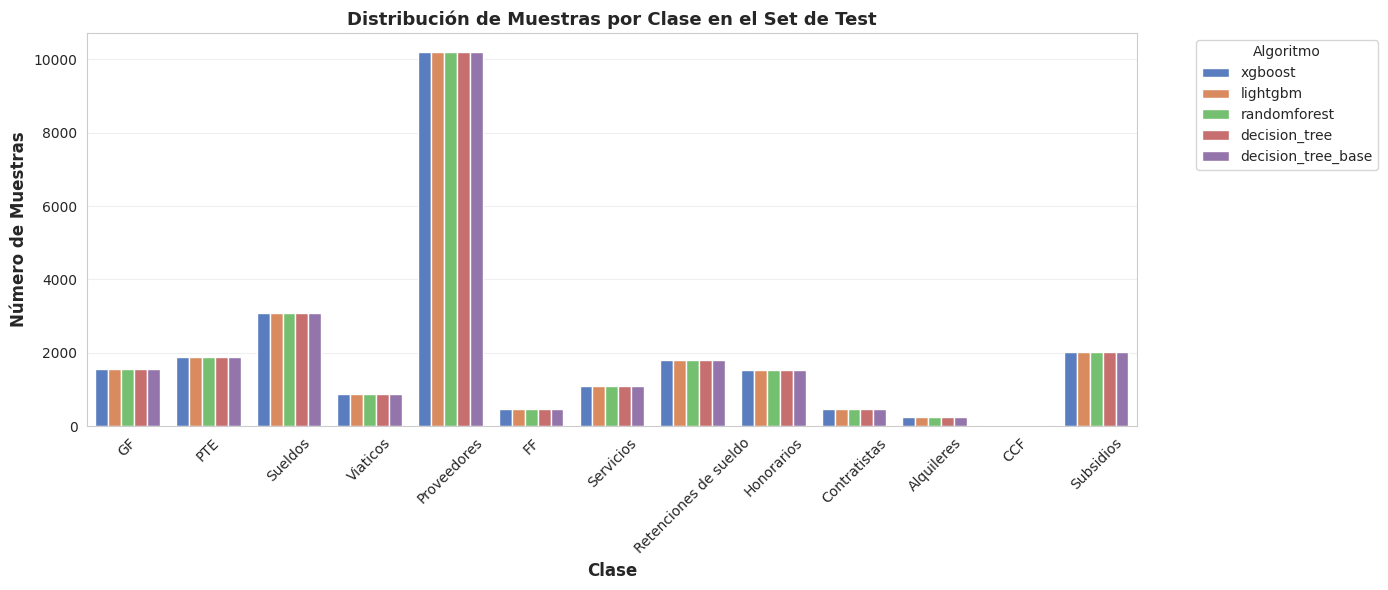

In [24]:
support_data = consolidado_clean[['algorithm', 'class', 'support']].copy()
support_data['support'] = support_data['support'].astype(int)

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=support_data, x='class', y='support', hue='algorithm', ax=ax, palette='muted')
ax.set_ylabel('Número de Muestras', fontsize=12, fontweight='bold')
ax.set_xlabel('Clase', fontsize=12, fontweight='bold')
ax.set_title('Distribución de Muestras por Clase en el Set de Test', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Algoritmo', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Ranking Final de Modelos


RANKING FINAL DE MODELOS
🥇 1. xgboost              | Accuracy: 0.966794 | Kappa: 0.958212 | F1-Score: 0.951013 | Score Final: 0.958673
🥈 2. lightgbm             | Accuracy: 0.966715 | Kappa: 0.958138 | F1-Score: 0.947615 | Score Final: 0.957489
🥉 3. randomforest         | Accuracy: 0.958276 | Kappa: 0.947469 | F1-Score: 0.938799 | Score Final: 0.948181
   4. decision_tree        | Accuracy: 0.927752 | Kappa: 0.908138 | F1-Score: 0.909798 | Score Final: 0.915229
   5. decision_tree_base   | Accuracy: 0.788382 | Kappa: 0.720672 | F1-Score: 0.613243 | Score Final: 0.707433


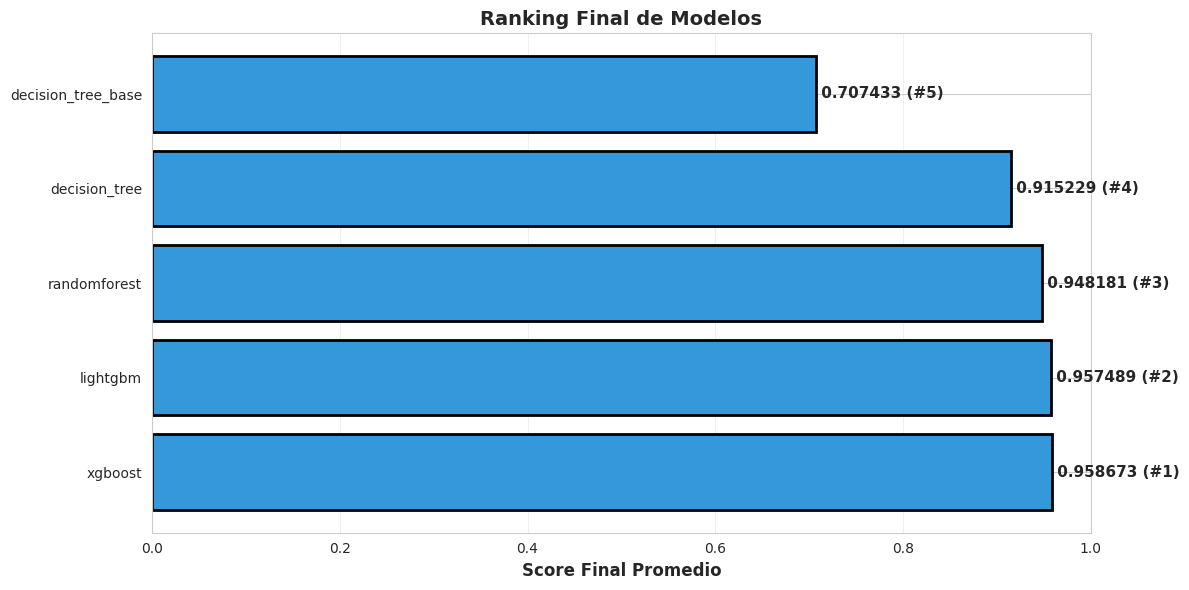

In [26]:
ranking = metricas_global[['algorithm', 'accuracy', 'kappa', 'f1_macro']].copy()
ranking['score_final'] = (ranking['accuracy'] + ranking['kappa'] + ranking['f1_macro']) / 3
ranking = ranking.sort_values('score_final', ascending=False).reset_index(drop=True)
ranking['posición'] = range(1, len(ranking) + 1)

print('\n' + '='*100)
print('RANKING FINAL DE MODELOS')
print('='*100)
for idx, row in ranking.iterrows():
    medal = '🥇' if idx == 0 else ('🥈' if idx == 1 else ('🥉' if idx == 2 else '  '))
    print(f"{medal} {idx+1}. {row['algorithm']:20s} | Accuracy: {row['accuracy']:.6f} | Kappa: {row['kappa']:.6f} | F1-Score: {row['f1_macro']:.6f} | Score Final: {row['score_final']:.6f}")
print('='*100)

fig, ax = plt.subplots(figsize=(12, 6))
colors_rank = '#3498db'
bars = ax.barh(ranking['algorithm'], ranking['score_final'], color=colors_rank, edgecolor='black', linewidth=2)
ax.set_xlabel('Score Final Promedio', fontsize=12, fontweight='bold')
ax.set_title('Ranking Final de Modelos', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1)
ax.grid(axis='x', alpha=0.3)

for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f' {width:.6f} (#{ranking.iloc[i]["posición"]:.0f})',
            ha='left', va='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

## Conclusiones

Este reporte presenta un análisis completo de los 4 modelos evaluados en el set de test. Los gráficos anteriores permiten:

1. **Comparar el desempeño global** de cada modelo
2. **Analizar métricas individuales** como accuracy, kappa y F1-score
3. **Evaluar el comportamiento por clase** para identificar clases problemáticas
4. **Revisar las matrices de confusión** para entender los errores específicos
5. **Establecer un ranking final** basado en un score combinado

Use este reporte para tomar decisiones sobre qué modelo seleccionar o cómo mejorar el desempeño.